**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---


- NOMBRE: Carlos Rodrigo Salguero Alcántara
- MATRÍCULA: A00833341


En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

- `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
- `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
- `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
- `fuel_type`: Tipo de combustible (gasolina o diésel)
- `aspiration`: Tipo de aspiración del motor (normal o turbo)
- `num_doors`: Número de puertas del automóvil (dos o cuatro)
- `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
- `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
- `engine_location`: Ubicación del motor (delantero o trasero)
- `wheel_base`: Distancia entre ejes (en pulgadas)
- `length`: Largo total del automóvil (en pulgadas)
- `width`: Ancho total del automóvil (en pulgadas)
- `height`: Altura total del automóvil (en pulgadas)
- `curb_weight`: Peso del automóvil sin carga (en libras)
- `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
- `num_cylinders`: Número de cilindros del motor
- `engine_size`: Tamaño del motor (en cc)
- `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
- `bore`: Diámetro del cilindro (en pulgadas)
- `stroke`: Carrera del pistón (en pulgadas)
- `compression_ratio`: Relación de compresión del motor
- `horsepower`: Potencia del motor (en caballos de fuerza)
- `peak_rpm`: Revoluciones máximas por minuto
- `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
- `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
- `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o _target_, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder _explícitamente_ todos los cuestionamientos.


In [1]:
import warnings 

warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Visual theme configuration


In [3]:
PRIMARY   = "#1F4E5F"
SECONDARY = "#C44E52"
ACCENT    = "#DD8452"
NEUTRAL   = "#6B7B8C"

CATEG_PALETTE = ["#1F4E5F", "#DD8452", "#55876B", "#C44E52", "#8172B3",
                 "#937860", "#5B8CA8", "#B0A160", "#A65C5C", "#6B7B8C"]

SEQ_CMAP = sns.light_palette(PRIMARY, as_cmap=True)
DIV_CMAP = sns.diverging_palette(15, 200, s=75, l=45, as_cmap=True)            

In [4]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#CCCCCC",
    "axes.titleweight":  "bold",
    "axes.titlecolor":   "#222222",
    "axes.labelcolor":   "#333333",
    "axes.labelweight":  "medium",
    "font.family":       "DejaVu Sans",
    "grid.color":        "#E8E8E8",
    "figure.dpi":        110,
})

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.

- Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
- Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
- Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.


In [5]:
cars_df = pd.read_csv("data/automobile_dataset.csv")
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel_type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num_doors          205 non-null    str    
 6   body_style         205 non-null    str    
 7   drive_wheels       205 non-null    str    
 8   engine_location    205 non-null    str    
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    str    
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non-null    in

In [6]:
n_num_before = cars_df.select_dtypes(include=np.number).shape[1]
n_txt_before = cars_df.select_dtypes(exclude=np.number).shape[1]
print(f"\nOriginal load  ->  numeric: {n_num_before} | text: {n_txt_before}")


Original load  ->  numeric: 12 | text: 14


In [7]:
cols_with_q = [c for c in cars_df.columns
               if cars_df[c].astype(str).str.contains(r"\?").any()]
print("Columns containing '?':", cols_with_q)

Columns containing '?': ['normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm']


In [8]:
cars_df = cars_df.replace("?", np.nan)
for col in cols_with_q:
    cars_df[col] = pd.to_numeric(cars_df[col], errors="coerce")

In [9]:
print("\nData types after conversion:")
print(cars_df.dtypes)


Data types after conversion:
symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_doors                str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_cylinders          int64
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                  int64
dtype: object


In [10]:
n_num_after = cars_df.select_dtypes(include=np.number).shape[1]
n_txt_after = cars_df.select_dtypes(exclude=np.number).shape[1]
print(f"\nAfter cleaning ->  numeric: {n_num_after} | text: {n_txt_after}")


After cleaning ->  numeric: 17 | text: 9


**Respuesta (pregunta 1)**

Al cargar el archivo, `info()` reporta **26 columnas**: **12 numéricas** (`int64`/`float64`) y **14 de texto** (`object`). Sin embargo, este conteo inicial está distorsionado porque varias columnas que en realidad son numéricas fueron leídas como texto por contener el símbolo `?`.

Las columnas que presentan el símbolo `?` son:

- `normalized_losses`
- `bore`
- `stroke`
- `horsepower`
- `peak_rpm`

Tras sustituir `?` por `NaN` y convertir esas cinco columnas a numérico, el conjunto queda con **17 columnas numéricas** y **9 columnas de texto (categóricas)**.


# Análisis exploratorio de datos (univariado)


2. Antes de iniciar con el análisis univariado, verifica si hay registros duplicados e imprime el porcentaje de faltantes por columna.

- Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
- Genera histogramas para las numéricas y diagramas de barras para las categóricas.


In [11]:
print(f"Duplicated rows: {cars_df.duplicated().sum()}")

Duplicated rows: 0


In [12]:
missing_pct = (cars_df.isna().mean() * 100).round(2)
print("\nMissing values (%) per column:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))


Missing values (%) per column:
normalized_losses    20.00
bore                  1.95
stroke                1.95
horsepower            0.98
peak_rpm              0.98
dtype: float64


In [13]:
num_cols = cars_df.select_dtypes(include=np.number).columns
cat_cols = cars_df.select_dtypes(exclude=np.number).columns
num_desc = cars_df[num_cols].describe().T
num_desc["skew"] = cars_df[num_cols].skew()
num_desc["kurtosis"] = cars_df[num_cols].kurtosis()

In [14]:
print("\nNumeric descriptive statistics:")
display(num_desc.round(2))


Numeric descriptive statistics:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
symboling,205.0,0.83,1.25,-2.00,0.00,1.00,2.00,3.00,0.21,-0.68
normalized_losses,164.0,122.00,35.44,65.00,94.00,115.00,150.00,256.00,0.77,0.53
wheel_base,205.0,98.76,6.02,86.60,94.50,97.00,102.40,120.90,1.05,1.02
length,205.0,174.05,12.34,141.10,166.30,173.20,183.10,208.10,0.16,-0.08
width,205.0,65.91,2.15,60.30,64.10,65.50,66.90,72.30,0.90,0.70
height,205.0,53.72,2.44,47.80,52.00,54.10,55.50,59.80,0.06,-0.44
curb_weight,205.0,2555.57,520.68,1488.00,2145.00,2414.00,2935.00,4066.00,0.68,-0.04
num_cylinders,205.0,4.38,1.08,2.00,4.00,4.00,4.00,12.00,2.82,13.71
engine_size,205.0,126.91,41.64,61.00,97.00,120.00,141.00,326.00,1.95,5.31
bore,201.0,3.33,0.27,2.54,3.15,3.31,3.59,3.94,0.02,-0.83


In [15]:
print("\nCategorical descriptive statistics:")
display(cars_df[cat_cols].describe().T)


Categorical descriptive statistics:


,count,unique,top,freq
make,205,22,toyota,32
fuel_type,205,2,gas,185
aspiration,205,2,std,168
num_doors,205,2,four,116
body_style,205,5,sedan,96
drive_wheels,205,3,fwd,120
engine_location,205,2,front,202
engine_type,205,7,ohc,148
fuel_system,205,8,mpfi,94


In [16]:
print("\nFrequency tables (categorical):")
for c in cat_cols:
    print(f"\n--- {c} ---")
    print(cars_df[c].value_counts())


Frequency tables (categorical):

--- make ---
make
toyota           32
nissan           18
mazda            17
honda            13
mitsubishi       13
subaru           12
volkswagen       12
peugot           11
volvo            11
dodge             9
bmw               8
mercedes-benz     8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64

--- fuel_type ---
fuel_type
gas       185
diesel     20
Name: count, dtype: int64

--- aspiration ---
aspiration
std      168
turbo     37
Name: count, dtype: int64

--- num_doors ---
num_doors
four    116
two      89
Name: count, dtype: int64

--- body_style ---
body_style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

--- drive_wheels ---
drive_wheels
fwd    120
rwd     76
4wd      9
Name: count, dtype: in

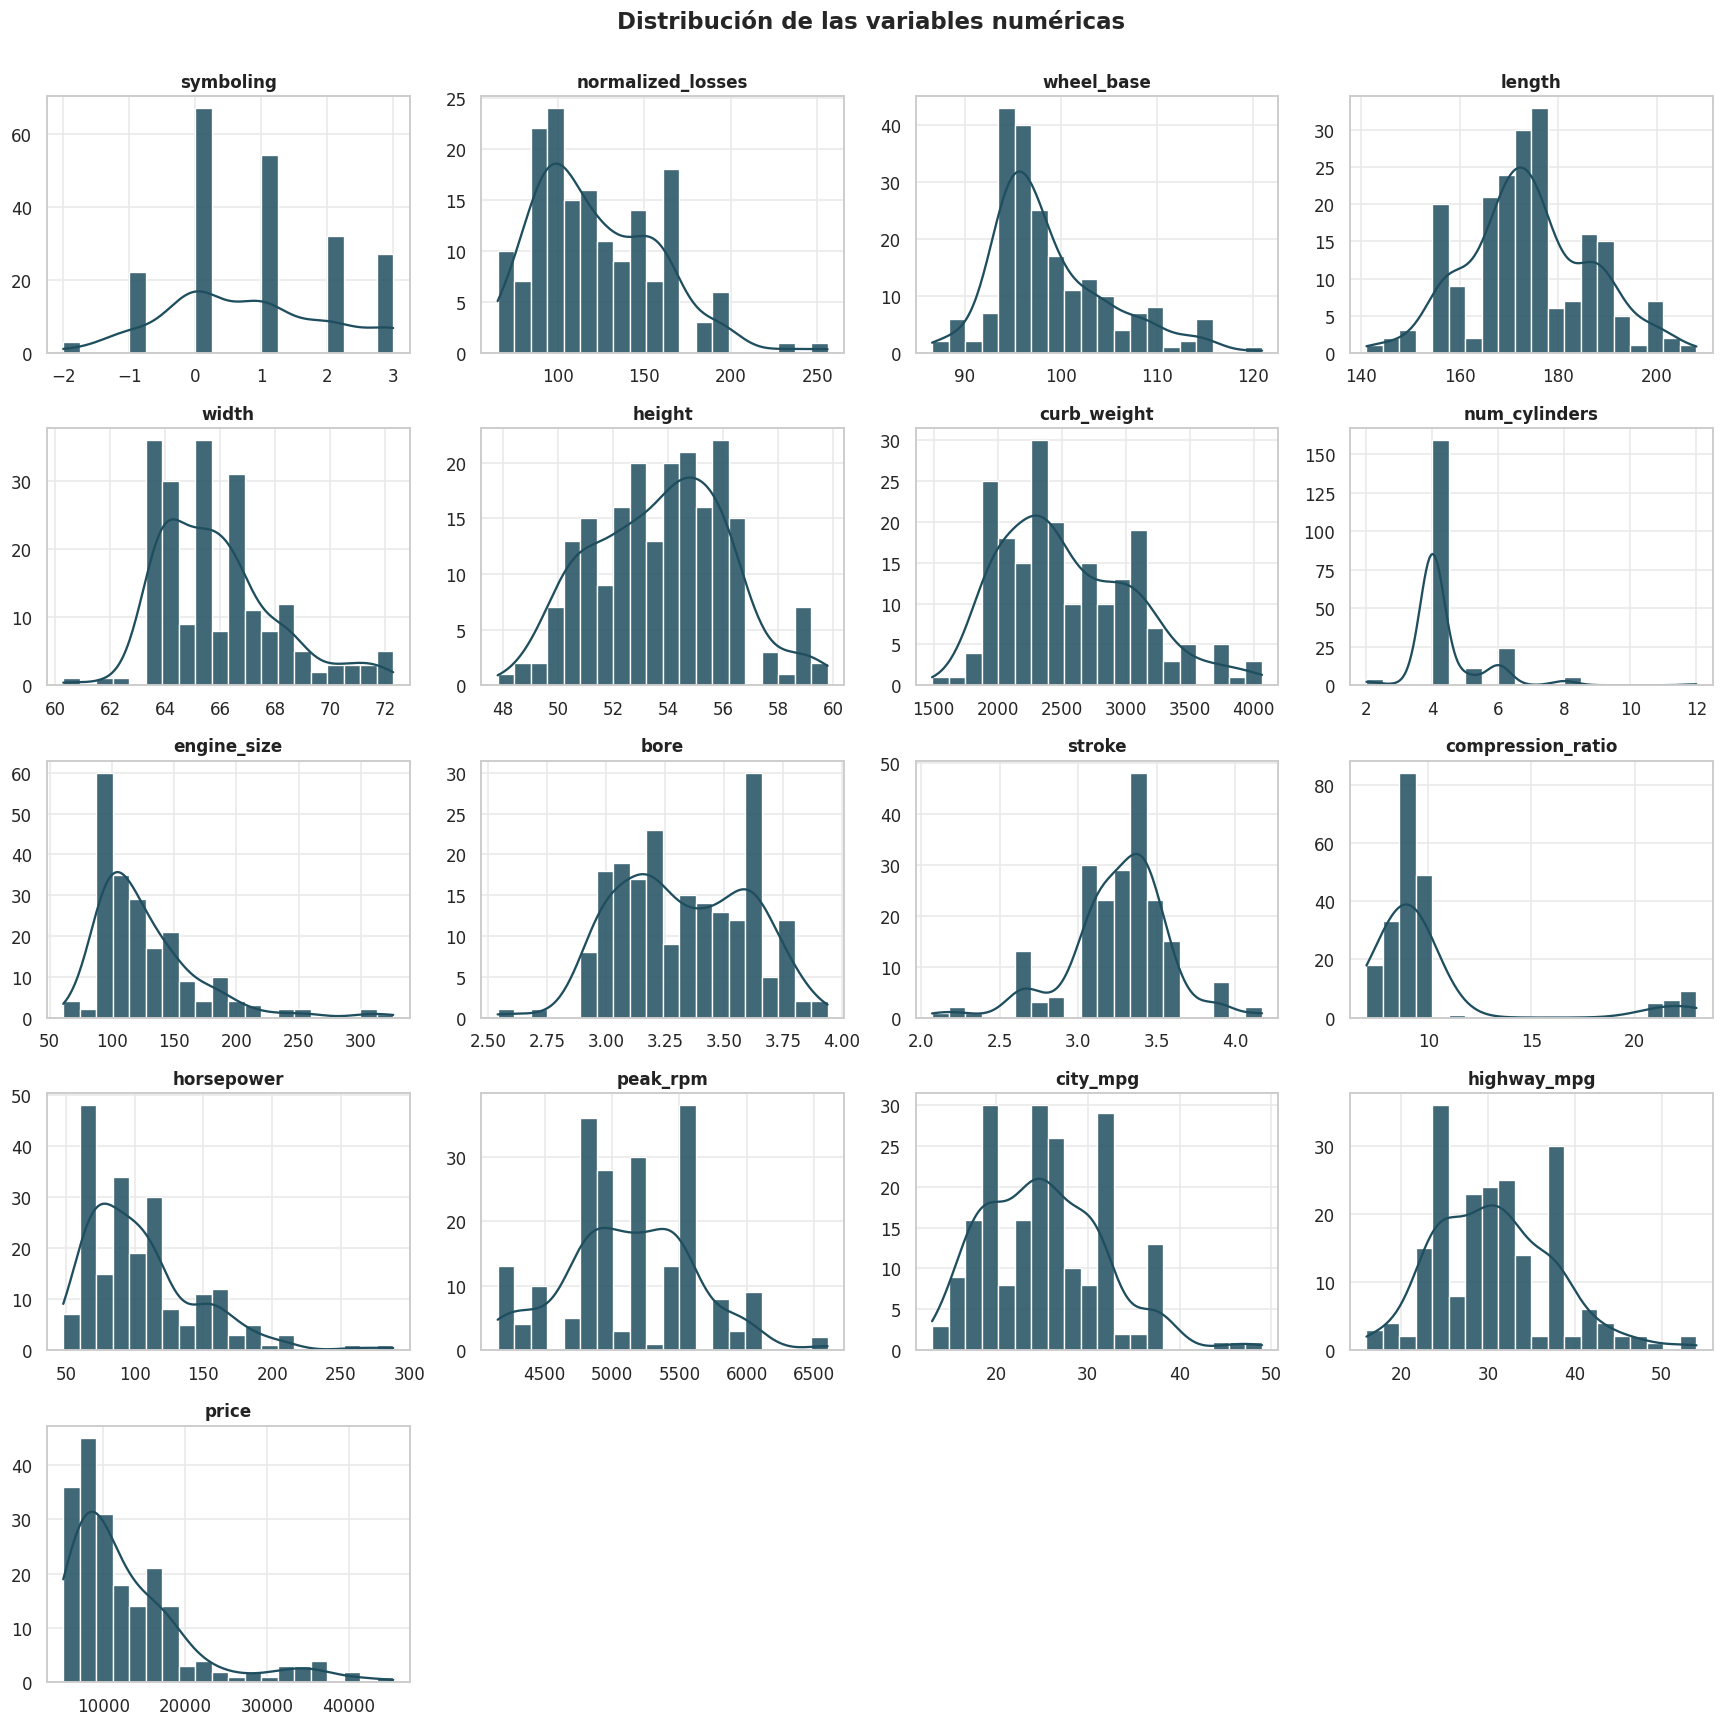

In [17]:
n = len(num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    sns.histplot(cars_df[col].dropna(), bins=20, kde=True,
                 color=PRIMARY, edgecolor="white", alpha=0.85, ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(
  "Distribución de las variables numéricas",
  fontsize=15,
  fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

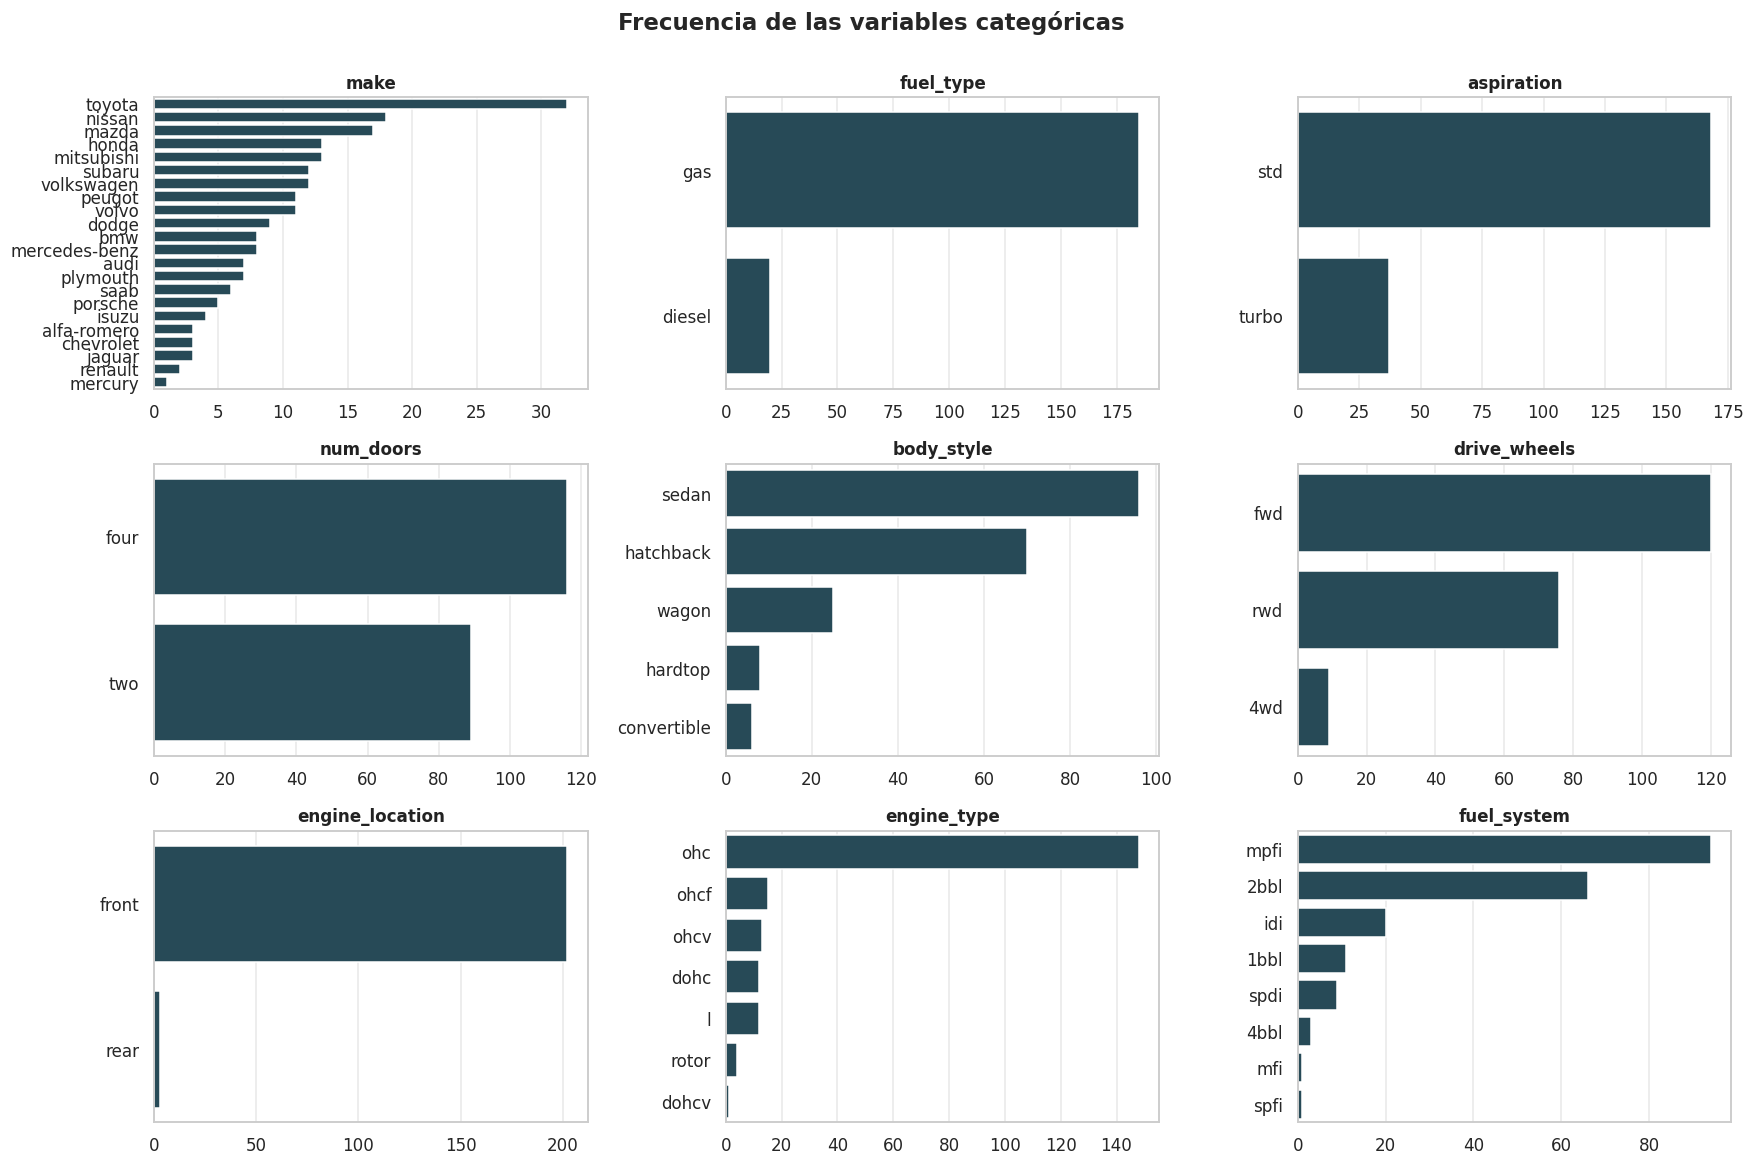

In [18]:
m = len(cat_cols)
ncols = 3
nrows = int(np.ceil(m / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.6 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, cat_cols):
    order = cars_df[col].value_counts().index
    sns.countplot(y=cars_df[col], order=order, color=PRIMARY, ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")

for ax in axes[m:]:
    ax.set_visible(False)

fig.suptitle(
  "Frecuencia de las variables categóricas", 
  fontsize=15, 
  fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

**Respuesta (pregunta 2)**

- **Duplicados:** no existen registros duplicados (0).
- **Faltantes:** la única columna con un porcentaje considerable es `normalized_losses` (~**20%**). El resto presenta faltantes menores: `bore` y `stroke` (~2%), `horsepower` y `peak_rpm` (~1%).
- **Distribuciones numéricas:** variables como `price`, `engine_size`, `horsepower` y `normalized_losses` muestran **asimetría positiva** (curtosis y _skew_ altos), con una cola larga hacia valores grandes; `compression_ratio` es bimodal por la mezcla de motores gasolina/diésel.
- **Categóricas:** predominan los autos a `gas`, aspiración `std`, carrocería `sedan` y tracción `fwd`; los fabricantes con mayor frecuencia son Toyota, Nissan y Honda. La fuerte asimetría justifica usar la **mediana** para imputar más adelante.


# Análisis exploratorio de datos (bivariado)


3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:

- Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
- Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
- Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada con color por fabricante.
- Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.


In [19]:
dw_order = ["fwd", "rwd", "4wd"]
ct = pd.crosstab(cars_df["make"], cars_df["drive_wheels"], normalize="index")
ct = ct.reindex(columns=[c for c in dw_order if c in ct.columns])
ct = ct.loc[ct.index.sort_values()]

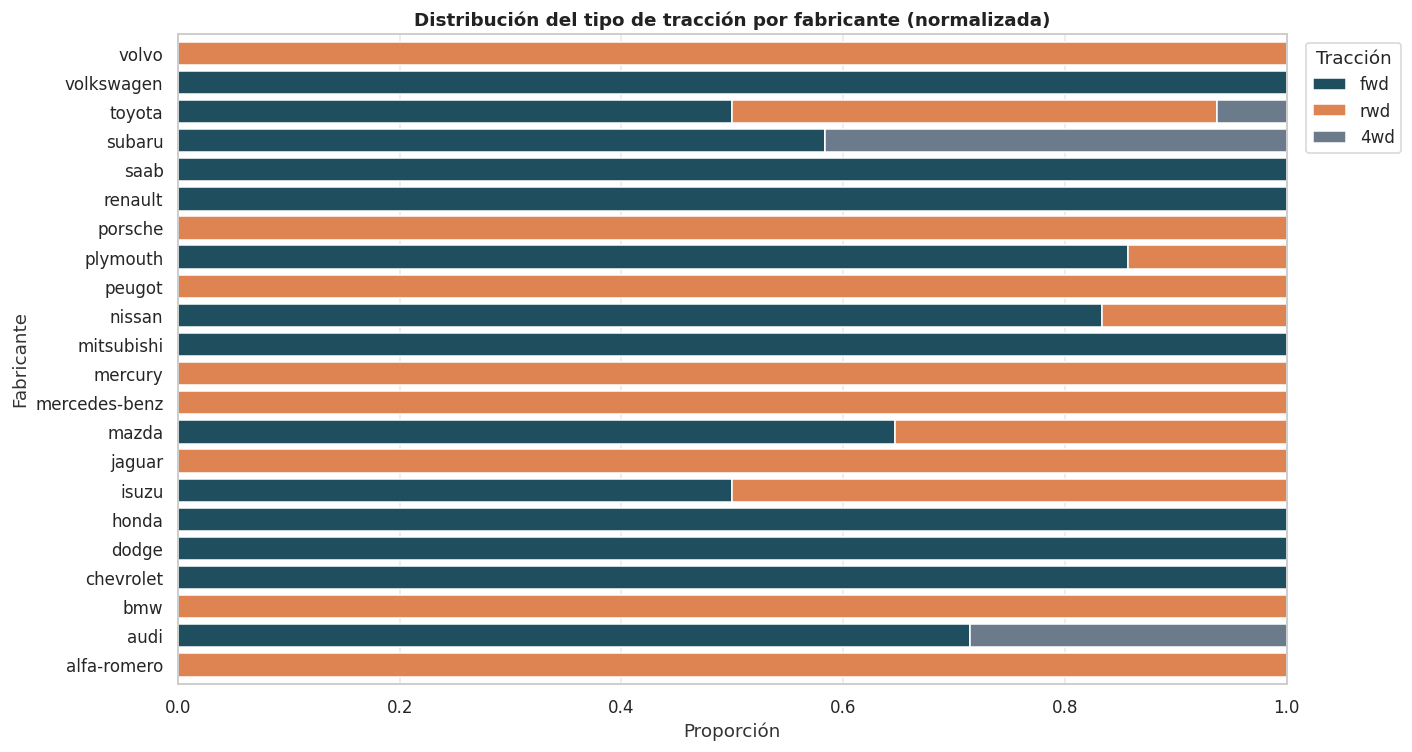

In [20]:
fig, ax = plt.subplots(figsize=(13, 7))
ct.plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=[PRIMARY, ACCENT, NEUTRAL], 
        edgecolor="white",
        width=0.8,
)

ax.set_title("Distribución del tipo de tracción por fabricante (normalizada)")
ax.set_xlabel("Proporción") 
ax.set_ylabel("Fabricante")
ax.legend(title="Tracción", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.margins(y=0.01)

plt.tight_layout()
plt.show()

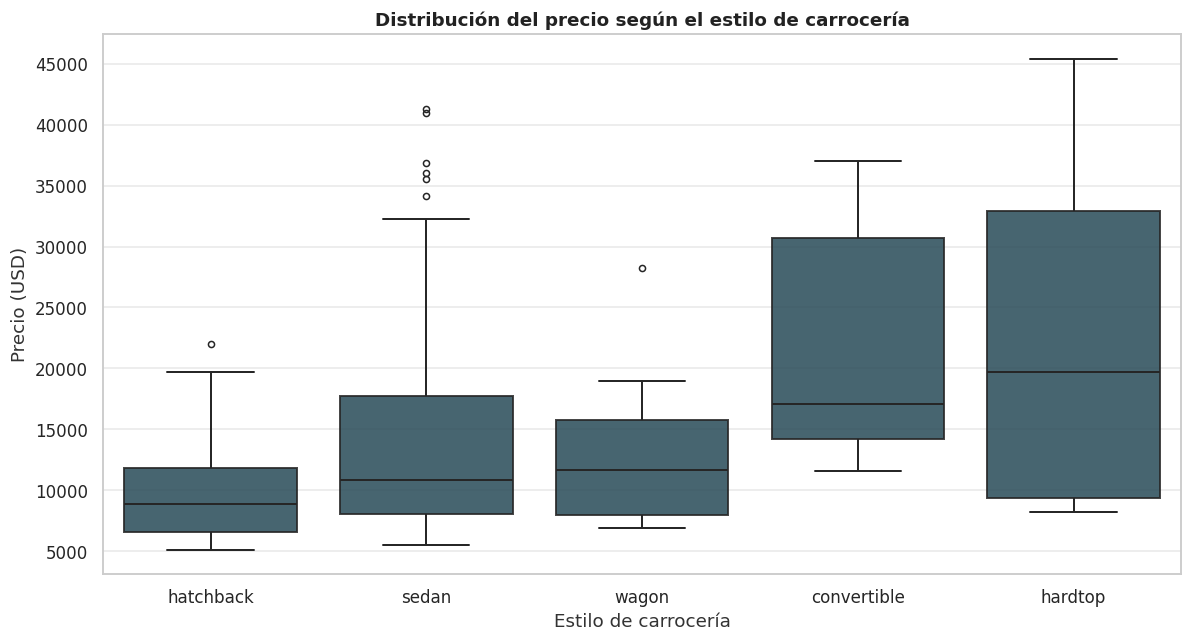

In [21]:
order = cars_df.groupby("body_style")["price"].median().sort_values().index
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=cars_df, x="body_style", y="price", order=order,
            color=PRIMARY, fliersize=4, linewidth=1.3,
            boxprops=dict(alpha=0.85), ax=ax)
            
ax.set_title("Distribución del precio según el estilo de carrocería")
ax.set_xlabel("Estilo de carrocería")
ax.set_ylabel("Precio (USD)")

plt.tight_layout()
plt.show()

In [22]:
top10 = cars_df.nlargest(10, "price").reset_index(drop=True)
makes = top10["make"].unique()
cmap = {mk: CATEG_PALETTE[i % len(CATEG_PALETTE)] for i, mk in enumerate(makes)}
colors = top10["make"].map(cmap)

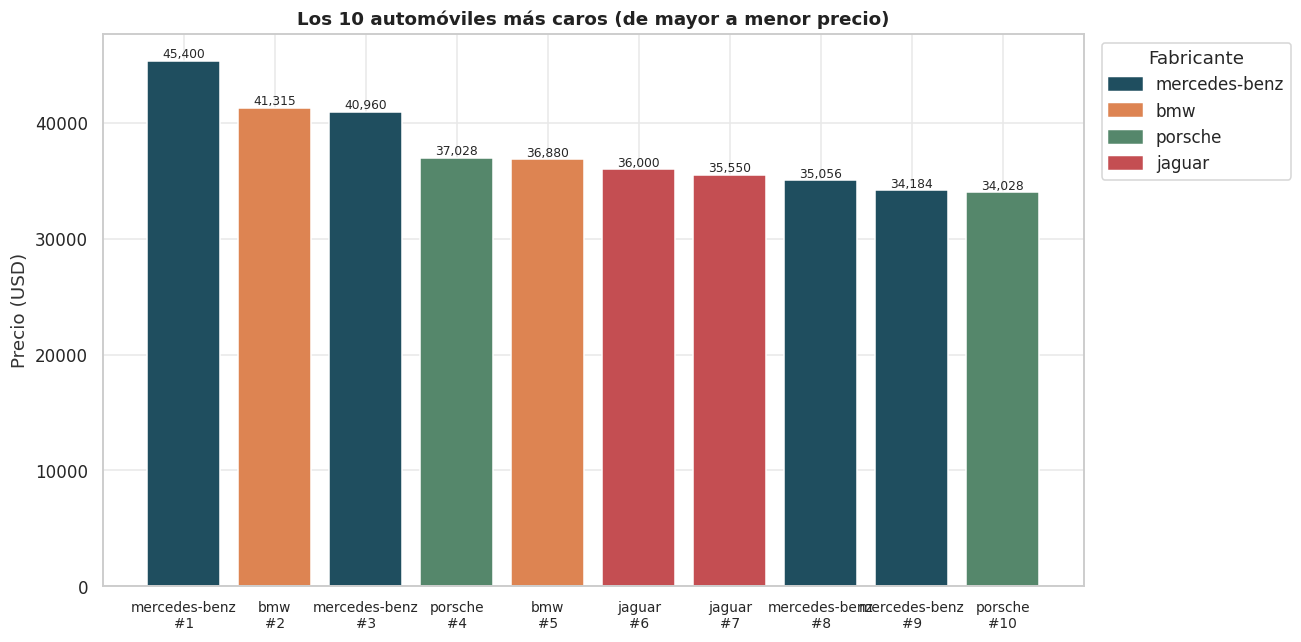

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
  range(len(top10)), top10["price"], color=colors, edgecolor="white"
)

ax.set_xticks(range(len(top10)))
ax.set_xticklabels([f"{mk}\n#{i+1}" for i, mk in enumerate(top10["make"])],
                   fontsize=9)

ax.set_title("Los 10 automóviles más caros (de mayor a menor precio)")
ax.set_ylabel("Precio (USD)")

for b, p in zip(bars, top10["price"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{p:,.0f}", ha="center", va="bottom", fontsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[mk]) for mk in makes]
ax.legend(handles, makes, title="Fabricante",
          bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

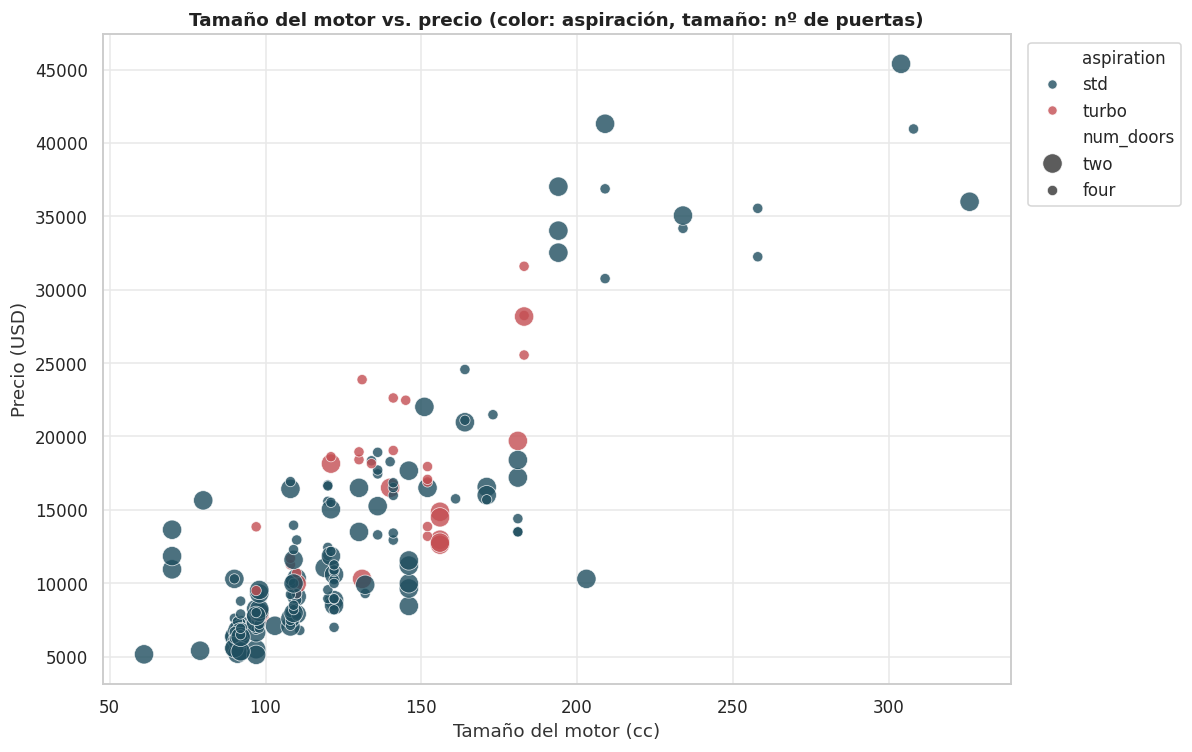

In [24]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=cars_df, x="engine_size", y="price",
                hue="aspiration", size="num_doors",
                sizes=(45, 160), palette=[PRIMARY, SECONDARY],
                alpha=0.8, edgecolor="white", linewidth=0.5, ax=ax)
                
ax.set_title("Tamaño del motor vs. precio (color: aspiración, tamaño: nº de puertas)")
ax.set_xlabel("Tamaño del motor (cc)"); ax.set_ylabel("Precio (USD)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Conclusiones (pregunta 3)**

- **Tracción por fabricante:** las marcas económicas/compactas (Honda, Toyota, Nissan, Mitsubishi) son mayoritariamente de tracción delantera (`fwd`), mientras que las marcas premium (Mercedes, BMW, Jaguar, Porsche) concentran tracción trasera (`rwd`). La tracción `4wd` es marginal y aparece solo en pocas marcas (p. ej. Subaru).
- **Precio por carrocería:** los `convertible` y `hardtop` presentan las medianas de precio más altas y mayor dispersión; `hatchback` y `sedan` son los más económicos. Existen valores atípicos elevados en `sedan` (modelos de lujo).
- **Top 10 más caros:** el segmento de mayor precio está dominado por marcas alemanas e inglesas de lujo (Mercedes-Benz, BMW, Jaguar, Porsche), confirmando la relación marca–precio.
- **Tamaño de motor vs. precio:** hay una relación **positiva** clara: a mayor `engine_size`, mayor precio. Los autos **turbo** tienden a ubicarse en precios más altos para un mismo tamaño de motor, y el número de puertas no muestra un patrón fuerte sobre el precio.


4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.

- ¿Cuáles son las tres variables más correlacionadas con el precio?


In [25]:
num_df = cars_df.select_dtypes(include=np.number)
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  

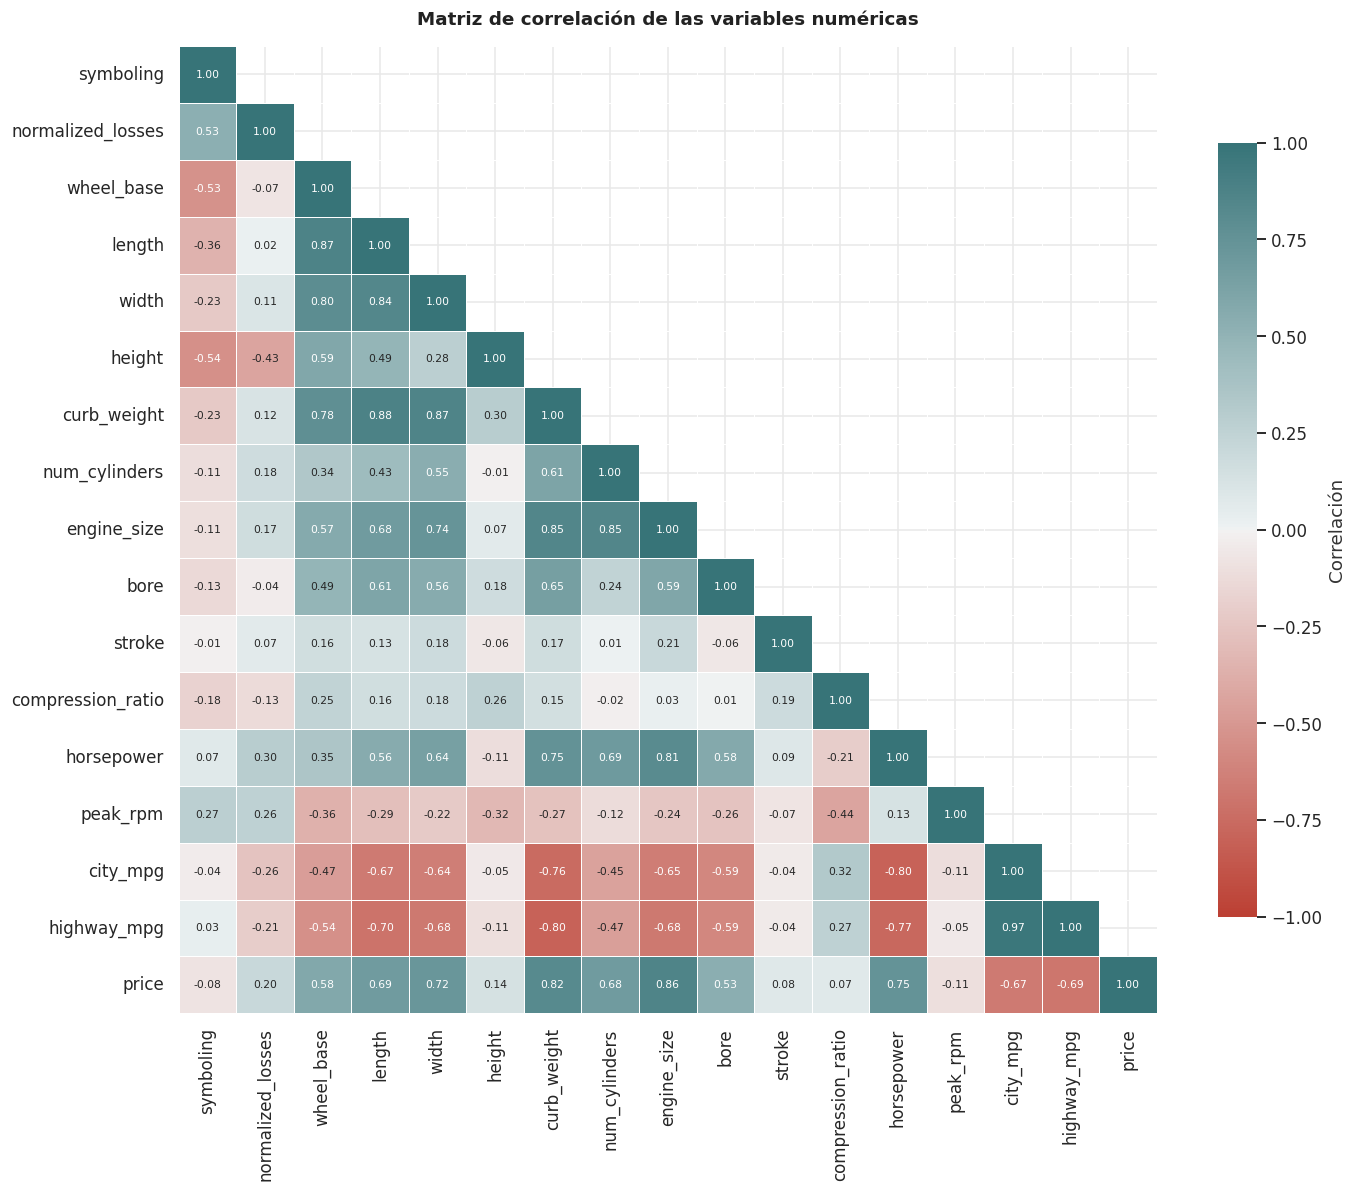

In [26]:
fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", annot_kws={"size": 7},
            cmap=DIV_CMAP, center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "Correlación"}, ax=ax)

ax.set_title("Matriz de correlación de las variables numéricas", pad=14)

plt.tight_layout()
plt.show()

In [27]:
top3 = corr["price"].drop("price").abs().sort_values(ascending=False).head(3)
print("Tres variables más correlacionadas con 'price':")
for var in top3.index:
    print(f"  {var:<14} r = {corr.loc[var, 'price']:.3f}")

Tres variables más correlacionadas con 'price':
  engine_size    r = 0.860
  curb_weight    r = 0.820
  horsepower     r = 0.750


**Respuesta (pregunta 4)**

Las tres variables más correlacionadas con `price` son:

1. **`engine_size`** (r ≈ 0.86)
2. **`curb_weight`** (r ≈ 0.82)
3. **`horsepower`** (r ≈ 0.75)

Esto indica que el precio está determinado principalmente por el tamaño del motor, el peso del vehículo y la potencia. Además, se aprecian fuertes correlaciones **entre predictores** (p. ej. `engine_size`–`curb_weight`, `city_mpg`–`highway_mpg`), lo que evidencia **multicolinealidad** y motiva el uso de PCA.


En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.


# Ingeniería de características


5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:

- Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
- Aplica `SimpleImputer` sobre `X` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
- Realiza el escalamiento del conjunto `X` ya imputado, para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.


PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.


In [28]:
y = cars_df["price"]
X = cars_df.select_dtypes(include=np.number).drop(columns=["price"])

print(f"Predictors (X): {X.shape[1]} numeric variables")
print(f"Columns: {list(X.columns)}")
print(f"\nPCA will generate min(n_samples, n_features) = "
      f"min({X.shape[0]}, {X.shape[1]}) = {min(X.shape)} principal components")

Predictors (X): 16 numeric variables
Columns: ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'num_cylinders', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg']

PCA will generate min(n_samples, n_features) = min(205, 16) = 16 principal components


In [29]:
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
  imputer.fit_transform(X), columns=X.columns, index=X.index
)

print(
  "\nRemaining missing values after imputation:",
  int(X_imputed.isna().sum().sum()),
)


Remaining missing values after imputation: 0


In [30]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
  scaler.fit_transform(X_imputed),
  columns=X.columns,
  index=X.index,
)

In [31]:
print("\nScaled data summary (mean ~ 0, std ~ 1):")
display(X_scaled.describe().loc[["mean", "std"]].round(3))


Scaled data summary (mean ~ 0, std ~ 1):


,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
mean,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000
std,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002


**Respuesta (pregunta 5)**

- `X` contiene **16 predictores numéricos** (todas las variables numéricas excepto `price`). Como PCA genera tantos componentes como `min(n_muestras, n_características)` y aquí `min(205, 16) = 16`, se generarán **16 componentes principales**.
- **Estrategia de imputación:** se eligió la **mediana** (`strategy="median"`) porque las variables numéricas presentan asimetría y valores atípicos (especialmente `normalized_losses`); la mediana es robusta frente a esos extremos, a diferencia de la media, que se vería arrastrada por la cola.
- **Escalamiento:** se aplicó `StandardScaler` (media 0, desviación 1). Es **indispensable antes de PCA**, pues el método se basa en la varianza; sin estandarizar, variables con escalas grandes como `curb_weight` o `engine_size` dominarían los componentes solo por su magnitud.


6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.

- Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
- Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.


In [32]:
pca = PCA()
scores = pca.fit_transform(X_scaled)

In [33]:
pc_names = [f"PC{i+1}" for i in range(scores.shape[1])]
pca_df = pd.DataFrame(scores, columns=pc_names, index=X.index)

print("Projected data (first rows):")
display(pca_df.head())

Projected data (first rows):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0.288788,-1.088415,-0.347735,-0.474581,0.267610,-0.273617,0.362346,0.185204,0.003853
1,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0.288788,-1.088415,-0.347735,-0.474581,0.267610,-0.273617,0.362346,0.185204,0.003853
2,0.634430,-1.372747,0.872496,0.998222,1.834717,-0.774751,-0.515065,1.370499,-1.130802,-1.013703,0.502983,0.657052,0.174955,-0.008520,0.118635,-0.111688
3,-0.361470,-0.919214,0.451578,-1.489124,-0.269938,-0.789900,0.000484,0.400032,0.293338,0.168137,0.039239,-0.022832,-0.078891,-0.391786,0.009265,0.053641
4,1.172393,-1.794960,0.183773,-1.083812,0.113486,-0.861858,-0.353900,0.870186,0.015429,-0.447054,-0.055376,-0.416053,-0.049431,0.079357,-0.198402,0.046303


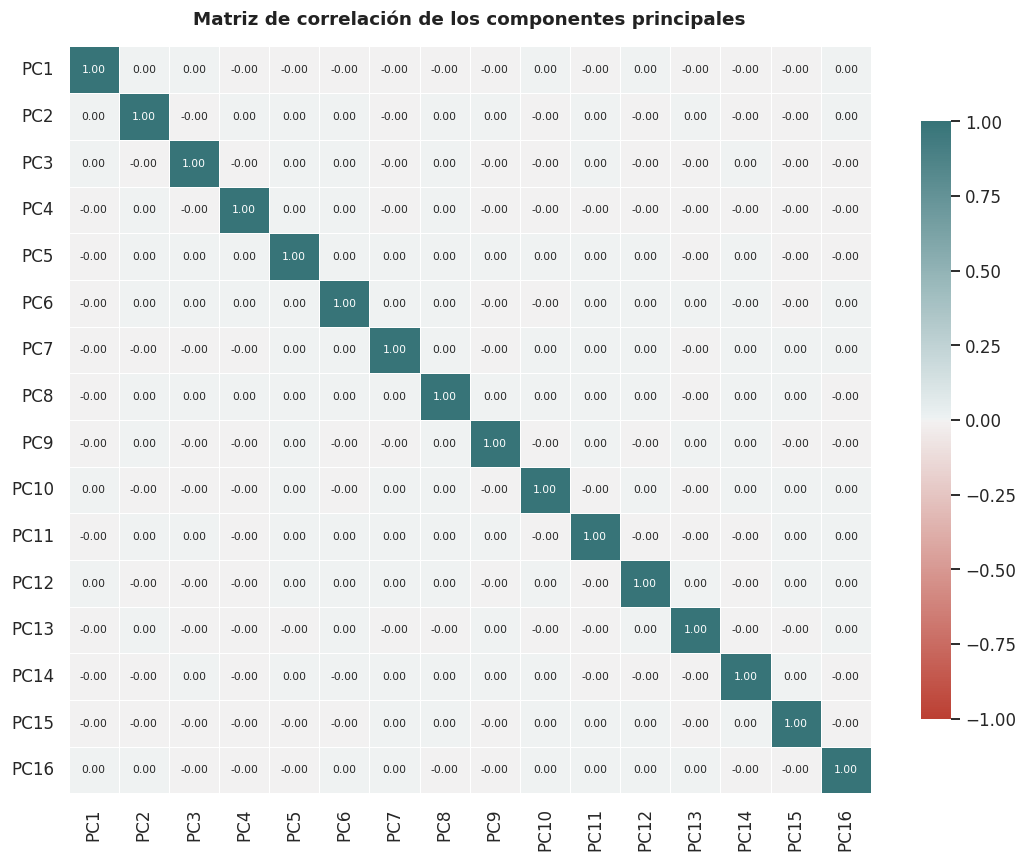

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pca_df.corr(), annot=True, fmt=".2f", annot_kws={"size": 7},
            cmap=DIV_CMAP, center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title("Matriz de correlación de los componentes principales", pad=14)

plt.tight_layout()
plt.show()

In [35]:
max_off = pca_df.corr().abs().where(~np.eye(len(pc_names), dtype=bool)).max().max()
print(f"Maximum off-diagonal |correlation| among components: {max_off:.6f}")

Maximum off-diagonal |correlation| among components: 0.000000


**Respuesta (pregunta 6)**

El mapa de calor de los componentes principales es prácticamente una **matriz identidad**: la diagonal vale 1 y todos los valores fuera de ella son ~0. Esto confirma que los componentes son **ortogonales (correlación cero)** entre sí, eliminando la multicolinealidad que se observaba entre las variables originales.


7. Obtén el porcentaje de varianza explicada por cada componente.

- Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.


In [36]:
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

var_table = pd.DataFrame({
    "Component": pc_names,
    "Explained variance (%)": (evr * 100).round(2),
    "Cumulative (%)": (cum * 100).round(2),
})
display(var_table)

,Component,Explained variance (%),Cumulative (%)
0,PC1,44.55,44.55
1,PC2,17.93,62.48
2,PC3,8.58,71.05
3,PC4,6.44,77.49
4,PC5,5.74,83.23
5,PC6,4.78,88.01
6,PC7,3.25,91.26
7,PC8,2.73,93.98
8,PC9,1.94,95.92
9,PC10,1.55,97.48


In [37]:
n_90 = int(np.argmax(cum >= 0.90) + 1)
print(f"\nMinimum components for > 90% variance: {n_90} "
      f"(cumulative = {cum[n_90-1]*100:.2f}%)")


Minimum components for > 90% variance: 7 (cumulative = 91.26%)


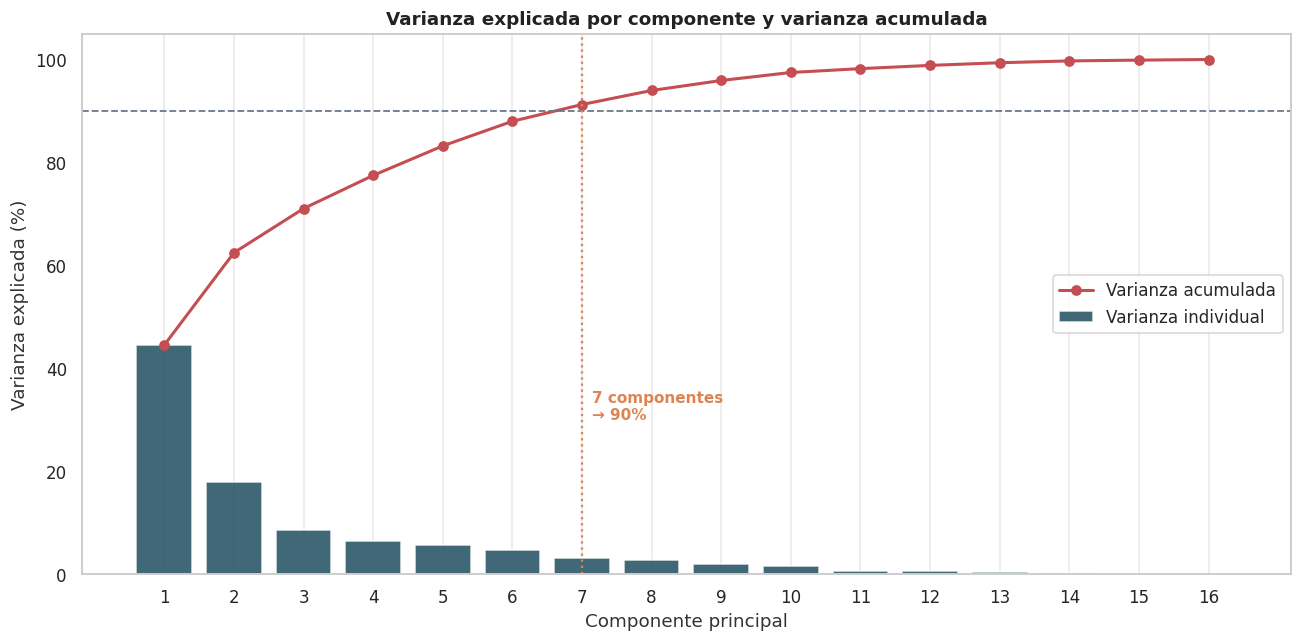

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(1, len(evr) + 1)
ax.bar(x, evr * 100, color=PRIMARY, alpha=0.85,
       edgecolor="white", label="Varianza individual")

ax.plot(x, cum * 100, color=SECONDARY, marker="o", linewidth=2,
        label="Varianza acumulada")
        
ax.axhline(90, color=NEUTRAL, linestyle="--", linewidth=1.2)
ax.axvline(n_90, color=ACCENT, linestyle=":", linewidth=1.5)
ax.text(n_90 + 0.15, 30, f"{n_90} componentes\n→ 90%",
        color=ACCENT, fontweight="bold", fontsize=10)

ax.set_title("Varianza explicada por componente y varianza acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Varianza explicada (%)")
ax.set_xticks(x)
ax.legend(loc="center right")
ax.grid(axis="y")

plt.tight_layout()
plt.show()

**Respuesta (pregunta 7)**

El primer componente explica ~44.6% de la varianza y el segundo ~17.9%. Acumulando, se necesitan **7 componentes principales** para superar el **90%** de la varianza total (acumulado ≈ 91.3%). Por lo tanto, se reduce de 16 variables a **7 componentes** conservando más del 90% de la información.


8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.

- Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.


In [39]:
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=pc_names)
selected = pc_names[:n_90]

print(f"Loadings of the {n_90} selected components:")
display(loadings[selected].round(3))

Loadings of the 7 selected components:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
symboling,-0.097,-0.403,0.265,-0.072,-0.366,0.173,0.128
normalized_losses,0.016,-0.331,0.308,-0.343,-0.376,-0.492,-0.323
wheel_base,0.298,0.265,-0.029,-0.228,-0.004,-0.183,-0.106
length,0.338,0.139,-0.044,-0.194,-0.074,-0.082,-0.009
width,0.334,0.055,0.109,-0.098,-0.016,-0.107,0.140
height,0.114,0.422,-0.282,-0.186,-0.017,-0.214,-0.003
curb_weight,0.362,0.022,0.080,-0.025,-0.042,-0.014,0.061
num_cylinders,0.245,-0.114,0.177,0.552,0.237,-0.354,-0.068
engine_size,0.330,-0.082,0.199,0.296,0.109,0.016,-0.073
bore,0.263,0.003,-0.138,0.041,-0.373,0.512,0.126


In [40]:
pc1 = loadings["PC1"].reindex(loadings["PC1"].abs().sort_values(ascending=False).index)
colors = [SECONDARY if v < 0 else PRIMARY for v in pc1.values]

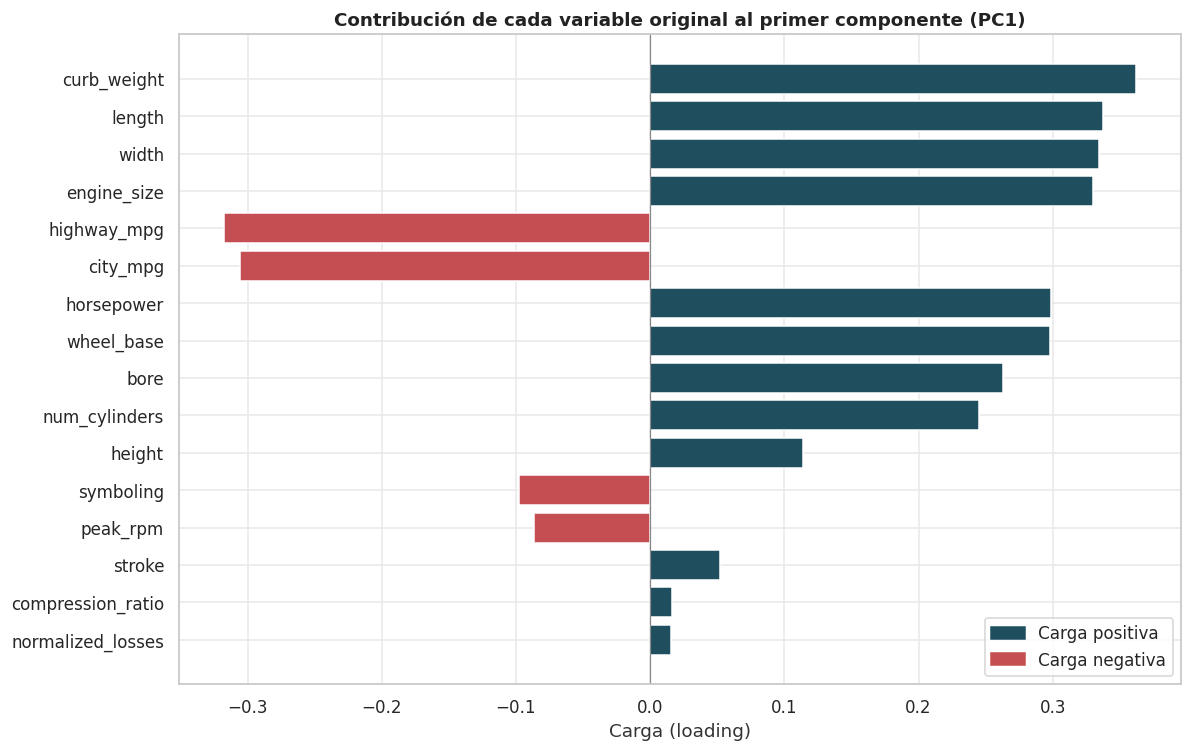

In [41]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(pc1.index, pc1.values, color=colors, edgecolor="white")
ax.invert_yaxis()
ax.axvline(0, color="#888888", linewidth=0.8)
ax.set_title("Contribución de cada variable original al primer componente (PC1)")

ax.set_xlabel("Carga (loading)")
handles = [plt.Rectangle((0, 0), 1, 1, color=PRIMARY),
           plt.Rectangle((0, 0), 1, 1, color=SECONDARY)]
ax.legend(handles, ["Carga positiva", "Carga negativa"], loc="lower right")

plt.tight_layout()
plt.show()

**Respuesta (pregunta 8)**

PC1 recibe cargas positivas altas y de magnitud similar de `curb_weight`, `length`, `width`, `engine_size` y `horsepower`, y cargas **negativas** de `city_mpg` y `highway_mpg`. Se interpreta como un eje de **“tamaño/potencia del vehículo”**: a mayor valor de PC1, autos más grandes, pesados y potentes (y por ende menos eficientes en combustible). Este componente captura justamente las variables más asociadas al precio.


9. Codifica las variables categóricas mediante _One-Hot Encoding_ y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.


In [42]:
cat_df = cars_df.select_dtypes(exclude=np.number)
print(f"Categorical variables ({cat_df.shape[1]}): {list(cat_df.columns)}")

Categorical variables (9): ['make', 'fuel_type', 'aspiration', 'num_doors', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'fuel_system']


In [43]:
encoder = OneHotEncoder(drop="first", sparse_output=False)
cat_encoded = encoder.fit_transform(cat_df)
cat_feature_names = encoder.get_feature_names_out(cat_df.columns)

In [44]:
cat_encoded_df = pd.DataFrame(cat_encoded, columns=cat_feature_names,
                              index=cars_df.index).astype(int)
print(f"Resulting dummy variables: {cat_encoded_df.shape[1]}")
display(cat_encoded_df.head())

Resulting dummy variables: 44


,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


**Respuesta (pregunta 9)**

Se codificaron las **9 variables categóricas** con _One-Hot Encoding_ usando `drop='first'`, lo que elimina una categoría de referencia por variable para evitar la **trampa de las variables dummy** (multicolinealidad perfecta). El resultado son **44 variables dummy** binarias.


10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.

- Almacena el dataframe resultante en archivo.


In [45]:
pca_selected = pca_df[selected].reset_index(drop=True)
cat_part     = cat_encoded_df.reset_index(drop=True)
target       = y.reset_index(drop=True)

In [46]:
final_df = pd.concat([pca_selected, cat_part, target], axis=1)
print(f"Final dataframe shape: {final_df.shape} "
      f"({len(selected)} PCs + {cat_part.shape[1]} dummies + 1 target)")
display(final_df.head())

Final dataframe shape: (205, 52) (7 PCs + 44 dummies + 1 target)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,make_audi,make_bmw,make_chevrolet,...,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi,price
0,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0,0,0,...,0,0,0,0,0,0,1,0,0,13495
1,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0,0,0,...,0,0,0,0,0,0,1,0,0,16500
2,0.634430,-1.372747,0.872496,0.998222,1.834717,-0.774751,-0.515065,0,0,0,...,1,0,0,0,0,0,1,0,0,16500
3,-0.361470,-0.919214,0.451578,-1.489124,-0.269938,-0.789900,0.000484,1,0,0,...,0,0,0,0,0,0,1,0,0,13950
4,1.172393,-1.794960,0.183773,-1.083812,0.113486,-0.861858,-0.353900,1,0,0,...,0,0,0,0,0,0,1,0,0,17450


In [47]:
out_path = "automobile_pca_features.csv"
final_df.to_csv(out_path, index=False)
print(f"\nSaved to: {out_path}")


Saved to: automobile_pca_features.csv


**Respuesta (pregunta 10)**

El dataframe final combina los **7 componentes principales** seleccionados, las **44 variables dummy** y la variable objetivo `price`, para un total de **52 columnas** y 205 registros. Se almacenó en el archivo `automobile_pca_features.csv`, listo para entrenar un modelo de regresión libre de multicolinealidad.


---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   Claude. (2026). *Anthropic* [Modelo de lenguaje grande], utilizado para verificación de código y contenido. https://claude.ai/

---
